In [5]:
import os
import time
import shutil
import pathlib
import itertools
from PIL import Image

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalMaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [12]:
data_path = "Malaria Cell\cell_images\cell_images" 

images = []
labels = []

for subfolder in os.listdir(data_path):
    
    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue
  
    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        images.append(image_path)
    
        labels.append(subfolder)
 
data = pd.DataFrame({'image': images, 'label': labels})

In [13]:
data.head()


,image,label
0,Malaria Cell\cell_images\cell_images\Parasitiz...,Parasitized
1,Malaria Cell\cell_images\cell_images\Parasitiz...,Parasitized
2,Malaria Cell\cell_images\cell_images\Parasitiz...,Parasitized
3,Malaria Cell\cell_images\cell_images\Parasitiz...,Parasitized
4,Malaria Cell\cell_images\cell_images\Parasitiz...,Parasitized


In [14]:
print("Original dataset size:", data.shape)
print("Label distribution:\n", data['label'].value_counts())


Original dataset size: (27560, 2)
Label distribution:
 label
Parasitized    13780
Uninfected     13780
Name: count, dtype: int64


In [15]:
strat = data['label']
train_df, dummy_df = train_test_split(data,  train_size= 0.82, shuffle= True, random_state= 123, stratify= strat)

strat = dummy_df['label']
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

In [16]:
print("Training set shape:", train_df.shape)
print("Validation set shape:", valid_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (22599, 2)
Validation set shape: (2480, 2)
Test set shape: (2481, 2)


In [17]:
batch_size = 32
img_size = (150, 150)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)

Found 22597 validated image filenames belonging to 2 classes.
Found 2480 validated image filenames belonging to 2 classes.
Found 2481 validated image filenames belonging to 2 classes.


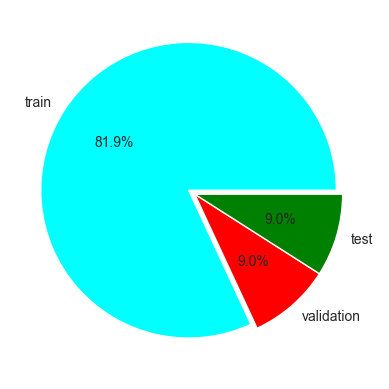

<Figure size 640x480 with 0 Axes>

In [18]:
plt.pie([len(train_gen), len(valid_gen), len(test_gen)],
        labels=['train', 'validation', 'test'], autopct='%.1f%%', colors=['aqua', 'red', 'green'], explode=(0.05, 0, 0))
plt.show()
plt.savefig('dataset_pie.png')

In [19]:
print(train_gen.class_indices)
print(test_gen.class_indices)
print(valid_gen.class_indices)

{'Parasitized': 0, 'Uninfected': 1}
{'Parasitized': 0, 'Uninfected': 1}
{'Parasitized': 0, 'Uninfected': 1}


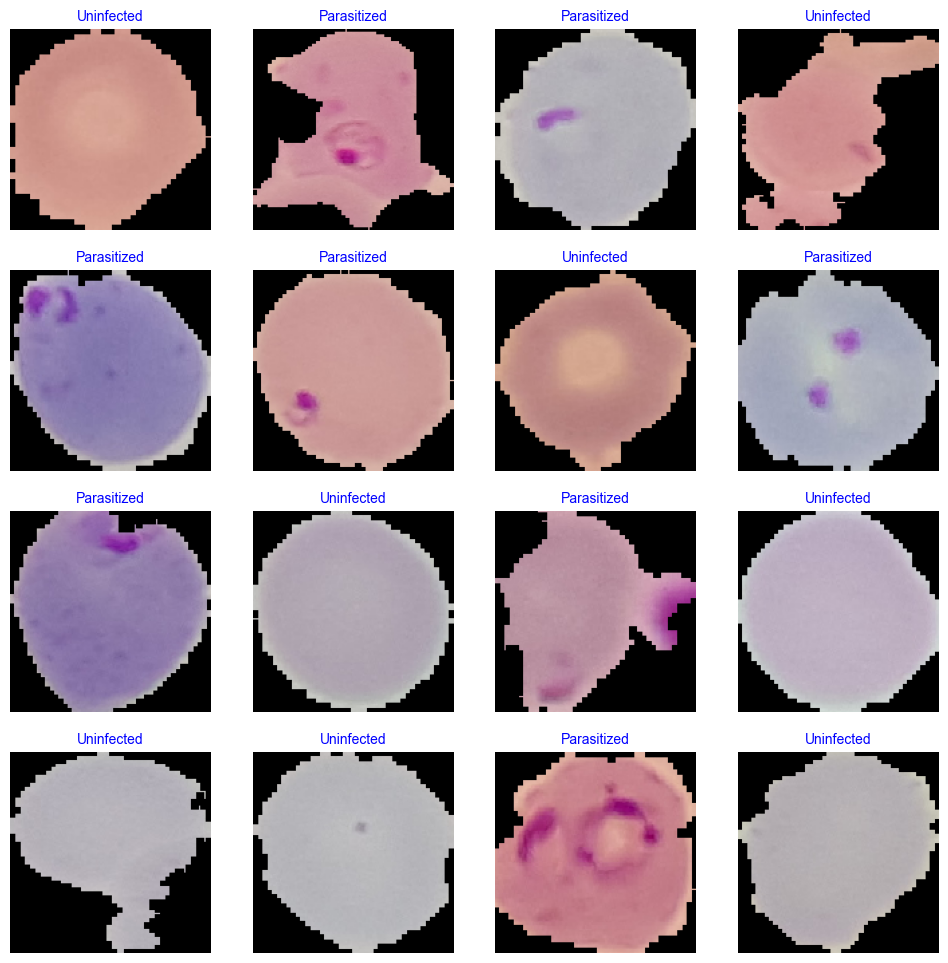

In [20]:
g_dict = train_gen.class_indices      
classes = list(g_dict.keys())       
images, labels = next(train_gen)      

plt.figure(figsize= (12, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       
    plt.imshow(image)
    index = np.argmax(labels[i])  
    class_name = classes[index]   
    plt.title(class_name, color= 'blue', fontsize= 10)
    plt.axis('off')
plt.show()

In [21]:
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        accuracy = logs.get('accuracy')
        val_accuracy = logs.get('val_accuracy')
        
        if accuracy:
            print(f"Epoch {epoch + 1}: Training accuracy is {accuracy:.4f}")
        if val_accuracy:
            print(f"Epoch {epoch + 1}: Validation accuracy is {val_accuracy:.4f}")
        
        if (accuracy and accuracy > 0.99) or (val_accuracy and val_accuracy > 0.99):
            print("\nReached 99% accuracy in training or validation, so cancelling training!")

In [22]:
model = Sequential()

model.add(tf.keras.layers.InputLayer(input_shape=(150, 150, 3)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())


model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())


model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) 
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))  
model.add(BatchNormalization())
model.add(Dropout(0.25))

model.add(Flatten())  

model.add(Dropout(0.3))  

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))


model.add(Dense(2, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001)))  



model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 1, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 307,074 (1.17 MB)

 Trainable params: 306,434 (1.17 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler


def lr_scheduler(epoch, lr):
    new_lr = lr * tf.math.exp(-0.1)
    return float(new_lr.numpy())

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=0.0001
)

callbacks = [
    myCallback(),
    LearningRateScheduler(lr_scheduler),
    reduce_lr
]

model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(
    train_gen,
    epochs=30,
    batch_size=32,
    verbose=2,
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/30


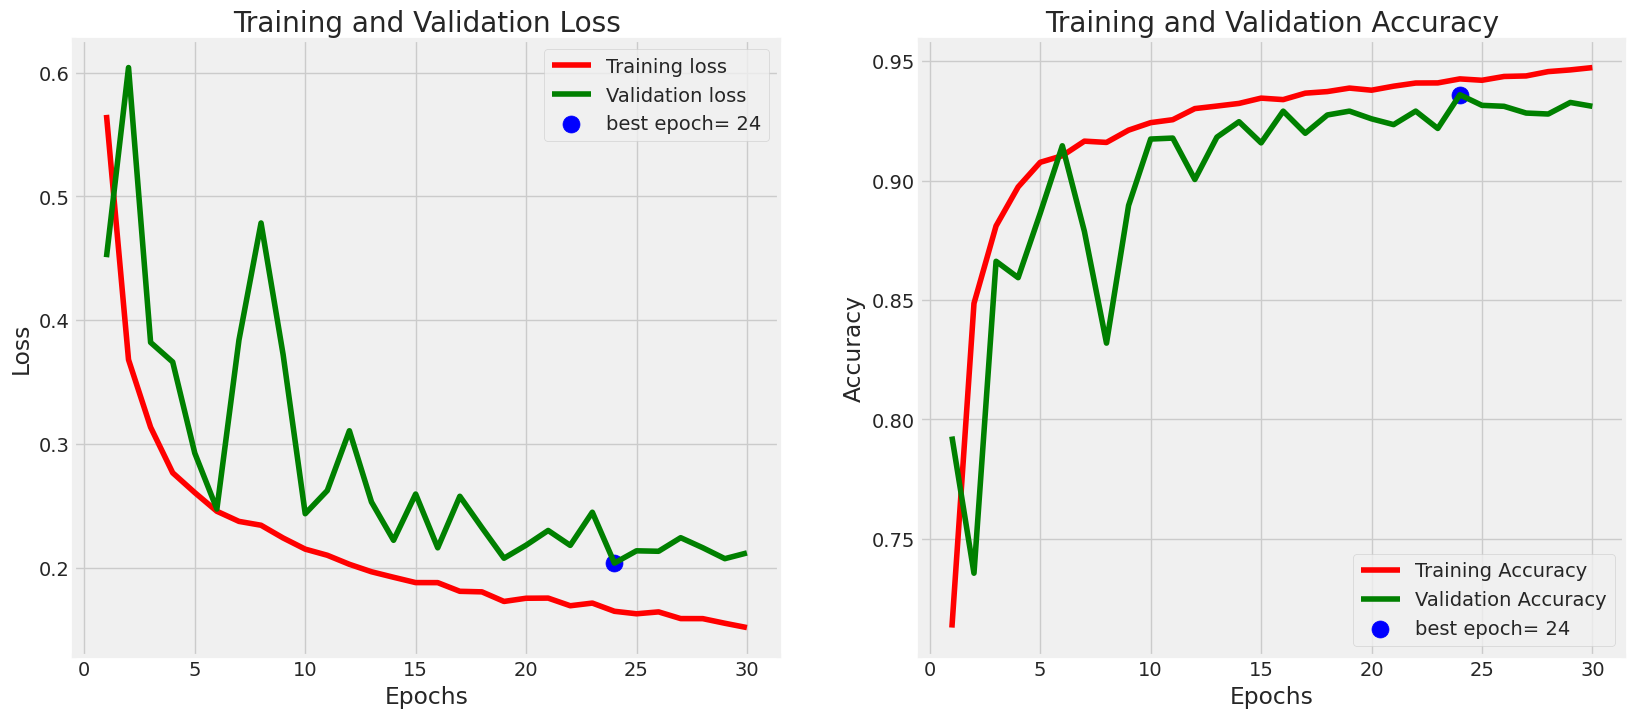

In [13]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout

plt.savefig('training_validation_plots.png')
plt.show()

In [14]:
loss, accuracy = model.evaluate(valid_gen)
print("Accuracy score:", accuracy)

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9367 - loss: 0.1874
Accuracy score: 0.931076169013977


In [15]:
test_loss, test_accuracy = model.evaluate(test_gen)

print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

78/78 ━━━━━━━━━━━━━━━━━━━━ 27s 348ms/step - accuracy: 0.9266 - loss: 0.2352
Test accuracy: 0.9311
Test loss: 0.2252


In [16]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

827/827 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - accuracy: 0.9442 - loss: 0.1644
827/827 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9311 - loss: 0.2119  
827/827 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9307 - loss: 0.2261  
Train Loss:  0.16823381185531616
Train Accuracy:  0.9444149136543274
--------------------
Valid Loss:  0.21197770535945892
Valid Accuracy:  0.931076169013977
--------------------
Test Loss:  0.22518838942050934
Test Accuracy:  0.931076169013977


In [17]:
classes = list(test_gen.class_indices.keys())

# Get predictions and convert to class indices
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(test_gen.classes, y_pred, target_names=classes))

78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step
              precision    recall  f1-score   support

 Parasitized       0.98      0.88      0.93      1241
  Uninfected       0.89      0.98      0.93      1240

    accuracy                           0.93      2481
   macro avg       0.93      0.93      0.93      2481
weighted avg       0.93      0.93      0.93      2481



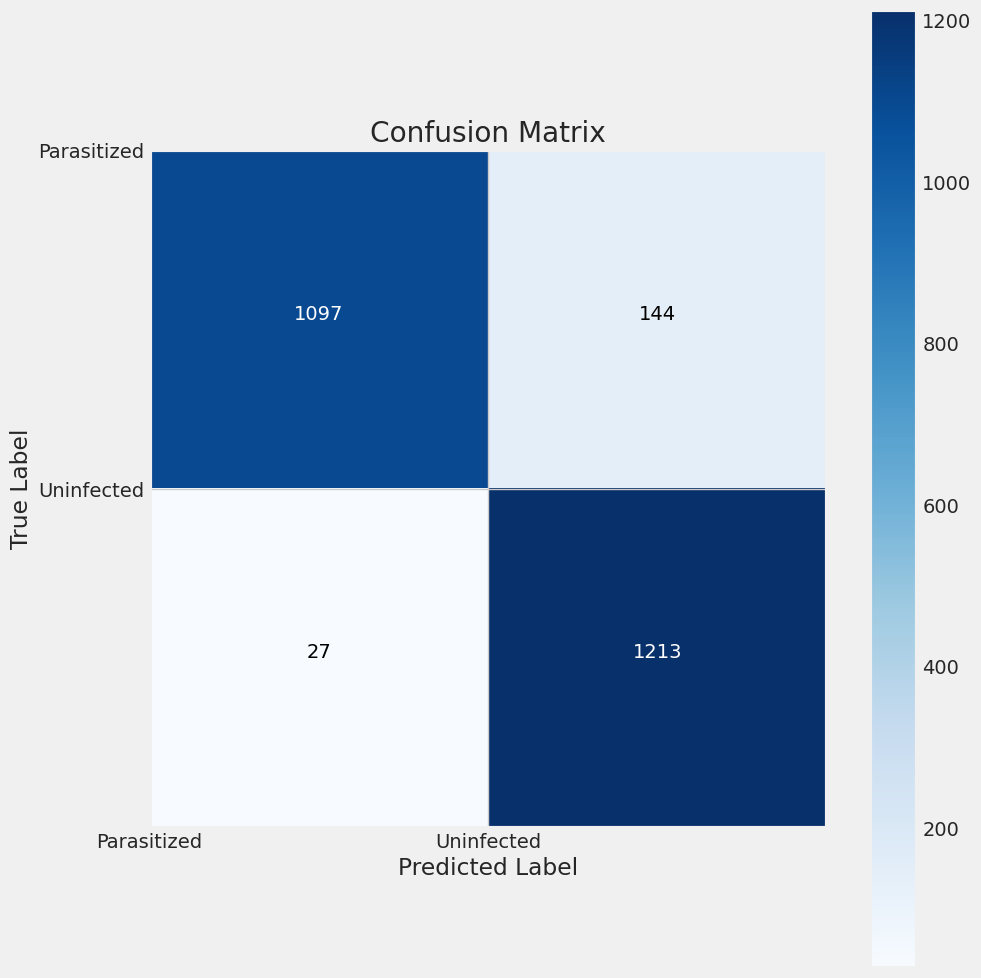

In [18]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks - 0.5, classes)  
plt.yticks(tick_marks - 0.5, classes) 


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [19]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Concatenate, BatchNormalization, Flatten, Dropout, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(150, 150, 3))

x = Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu')(inputs)
x = Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation='relu')(x)

pool_1 = MaxPooling2D(pool_size=(2, 2), padding='same')(x)
pool_2 = MaxPooling2D(pool_size=(2, 2), padding='same')(x)  

concatenated = Concatenate()([pool_1, pool_2])

x = BatchNormalization()(concatenated)

x = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu')(x)
x = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

x = Flatten()(x)
x = Dropout(0.3)(x)

x = Dense(61, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
outputs = Dense(2, activation='softmax', kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 148, 148,  │      3,584 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 146, 146,  │    147,584 │ conv2d_9[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 73, 73,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 73, 73,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 73, 73,    │          0 │ max_pooling2d_5[… │
│ (Concatenate)       │ 256)              │            │ max_pooling2d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │      1,024 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 71, 71,    │    147,520 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 69, 69,    │     36,928 │ conv2d_11[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 34, 34,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 34,    │        256 │ max_pooling2d_7[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 16, 16,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ max_pooling2d_8[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 16384)     │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 61)        │    999,485 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        124 │ dense_2[0][0]   

 Total params: 1,373,689 (5.24 MB)

 Trainable params: 1,372,921 (5.24 MB)

 Non-trainable params: 768 (3.00 KB)

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler


def lr_scheduler(epoch, lr):
    new_lr = lr * tf.math.exp(-0.1)
    return float(new_lr.numpy())

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=5, 
    min_lr=0.0001
)

callbacks = [
    myCallback(),
    LearningRateScheduler(lr_scheduler),
    reduce_lr
]

model.compile(optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(
    train_gen,
    epochs=20,
    batch_size=32,
    verbose=2,
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/20
Epoch 1: Training accuracy is 0.8478
Epoch 1: Validation accuracy is 0.9351
707/707 - 80s - 113ms/step - accuracy: 0.8478 - loss: 0.3642 - val_accuracy: 0.9351 - val_loss: 0.1985 - learning_rate: 9.0484e-04
Epoch 2/20
Epoch 2: Training accuracy is 0.9396
Epoch 2: Validation accuracy is 0.9137
707/707 - 58s - 83ms/step - accuracy: 0.9396 - loss: 0.1899 - val_accuracy: 0.9137 - val_loss: 0.2457 - learning_rate: 8.1873e-04
Epoch 3/20
Epoch 3: Training accuracy is 0.9472
Epoch 3: Validation accuracy is 0.9436
707/707 - 58s - 82ms/step - accuracy: 0.9472 - loss: 0.1668 - val_accuracy: 0.9436 - val_loss: 0.1862 - learning_rate: 7.4082e-04
Epoch 4/20
Epoch 4: Training accuracy is 0.9529
Epoch 4: Validation accuracy is 0.9532
707/707 - 58s - 82ms/step - accuracy: 0.9529 - loss: 0.1480 - val_accuracy: 0.9532 - val_loss: 0.1516 - learning_rate: 6.7032e-04
Epoch 5/20
Epoch 5: Training accuracy is 0.9595
Epoch 5: Validation accuracy is 0.9500
707/707 - 58s - 82ms/step - accuracy: 0.9595

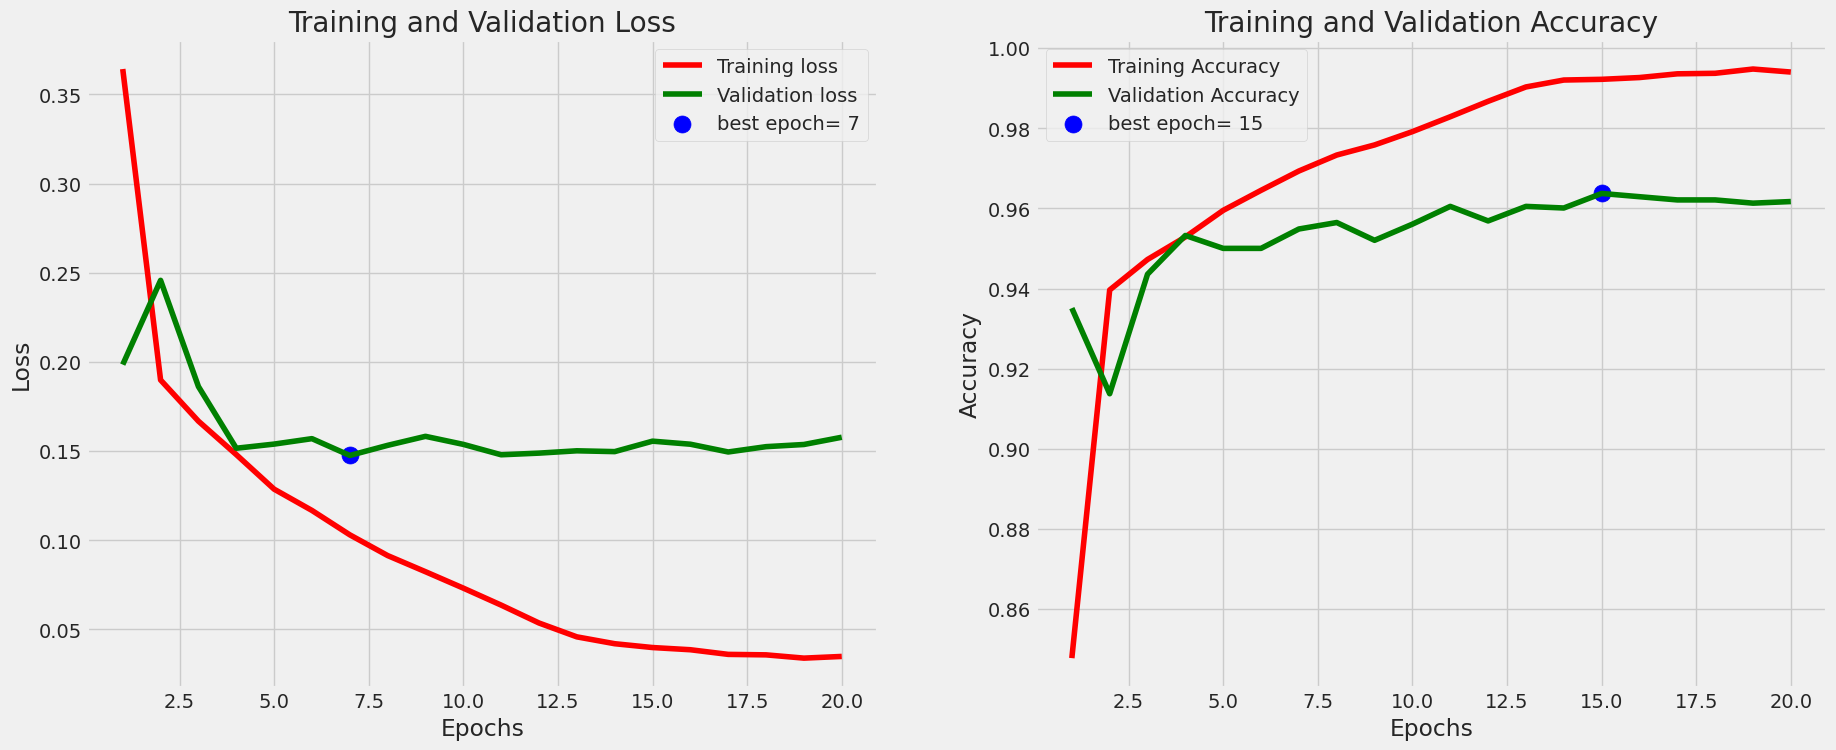

In [21]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout

plt.savefig('training_validation_plots.png')
plt.show()

In [22]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

827/827 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9978 - loss: 0.0252
827/827 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9618 - loss: 0.1569  
827/827 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9513 - loss: 0.1720   
Train Loss:  0.025089047849178314
Train Accuracy:  0.9976544380187988
--------------------
Valid Loss:  0.15776784718036652
Valid Accuracy:  0.9617089629173279
--------------------
Test Loss:  0.17135320603847504
Test Accuracy:  0.9512293338775635


In [23]:
classes = list(test_gen.class_indices.keys())

# Get predictions and convert to class indices
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(test_gen.classes, y_pred, target_names=classes))

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step
              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      1241
  Uninfected       0.94      0.96      0.95      1240

    accuracy                           0.95      2481
   macro avg       0.95      0.95      0.95      2481
weighted avg       0.95      0.95      0.95      2481



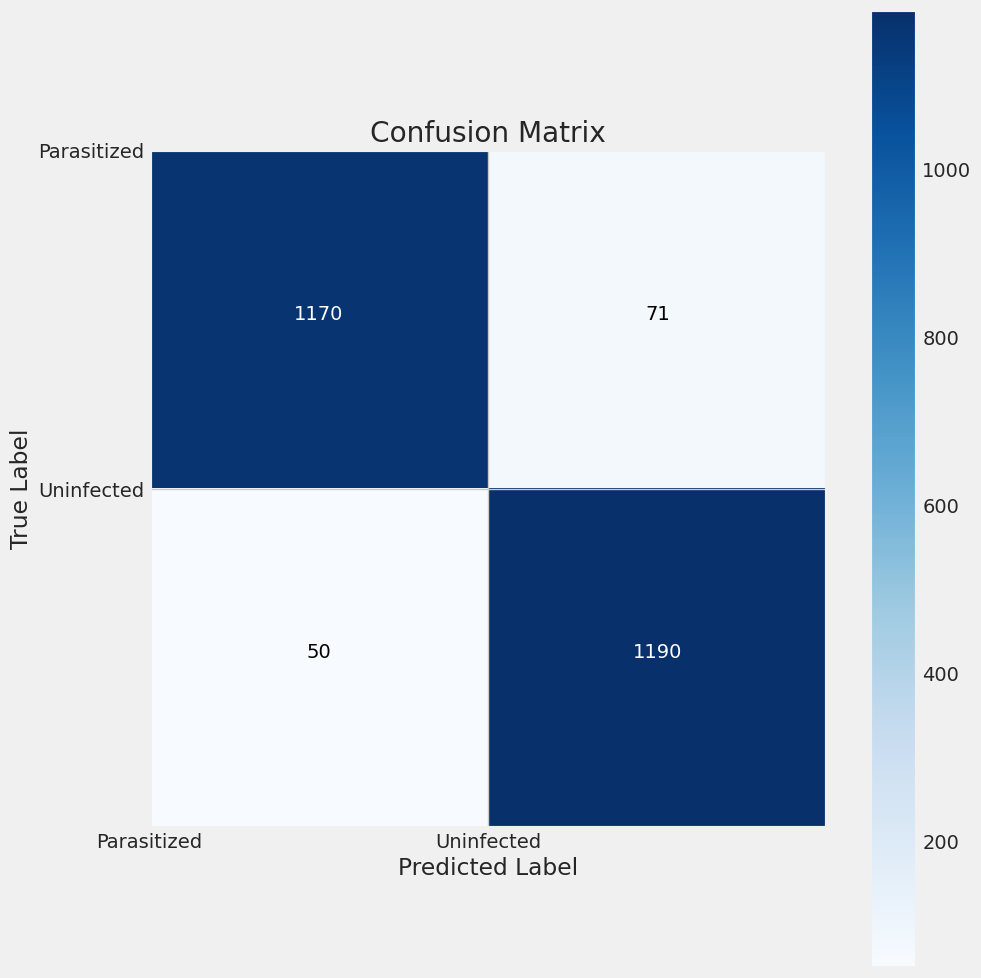

In [24]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks - 0.5, classes)  
plt.yticks(tick_marks - 0.5, classes) 


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [25]:
model.save('model1.h5')


# Hybrid model of CNN with XGBClassifier

In [38]:
# from tensorflow.keras.models import Model
# from xgboost import XGBClassifier
# import numpy as np
# from sklearn.metrics import accuracy_score

# batch_size = 16

# feature_extractor = Model(inputs=model.input, outputs=model.get_layer('flatten_1').output)

# train_features = []
# valid_features = []

# # Feature extraction for 2 epochs for the training set
# for epoch in range(2):
#     for batch_data, batch_labels in train_gen:
#         features_batch = feature_extractor.predict_on_batch(batch_data)
#         train_features.append(features_batch)
#         if len(train_features) * batch_size >= len(train_gen):
#             break

# train_features = np.concatenate(train_features)

# # Feature extraction for 2 epochs for the validation set
# for epoch in range(2):
#     for batch_data, batch_labels in valid_gen:
#         features_batch = feature_extractor.predict_on_batch(batch_data)
#         valid_features.append(features_batch)
#         if len(valid_features) * batch_size >= len(valid_gen):
#             break

# valid_features = np.concatenate(valid_features)

# train_features_flat = np.reshape(train_features, (train_features.shape[0], -1))
# valid_features_flat = np.reshape(valid_features, (valid_features.shape[0], -1))

# train_labels = np.array([label for _, label in train_gen])
# valid_labels = np.array([label for _, label in valid_gen])

# if len(train_labels.shape) > 1:
#     train_labels = np.argmax(train_labels, axis=1)

# if len(valid_labels.shape) > 1:
#     valid_labels = np.argmax(valid_labels, axis=1)

# assert train_features_flat.shape[0] == train_labels.shape[0], "Mismatch in training features and labels."
# assert valid_features_flat.shape[0] == valid_labels.shape[0], "Mismatch in validation features and labels."

# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# xgb_model.fit(train_features_flat, train_labels)

# valid_predictions = xgb_model.predict(valid_features_flat)

# accuracy = accuracy_score(valid_labels, valid_predictions)
# print("Validation Accuracy:", accuracy)

# np.save('train_features.npy', train_features_flat)
# np.save('valid_features.npy', valid_features_flat)


In [40]:
# xgb = XGBClassifier(n_estimators=100, learning_rate=0.1)

# xgb.fit(train_features_flat, train_labels)

# valid_preds = xgb.predict(valid_features_flat)

# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(valid_labels, valid_preds)

# print(f"XGBoost Classifier Accuracy: {accuracy * 100:.2f}%")


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━

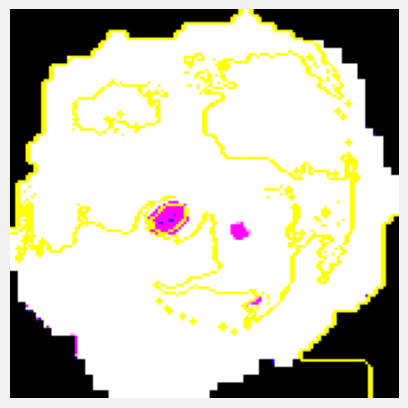

In [45]:
import lime
import lime.lime_image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from skimage.segmentation import mark_boundaries
from PIL import Image  
import matplotlib.pyplot as plt
import numpy as np

model = load_model('/kaggle/working/model1.h5')

explainer = lime.lime_image.LimeImageExplainer()

img_path = '/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png'
img = Image.open(img_path).resize((150, 150))
img = np.array(img)

if len(img.shape) == 2:
    img = np.stack((img,)*3, axis=-1)

img = preprocess_input(img)

def predict_fn(images):
    processed_images = np.array([preprocess_input(image) for image in images])
    return model.predict(processed_images)

explanation = explainer.explain_instance(img, predict_fn, top_labels=5, hide_color=0, num_samples=1000)

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.savefig("Cyst.png", dpi=300, bbox_inches='tight')

plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━

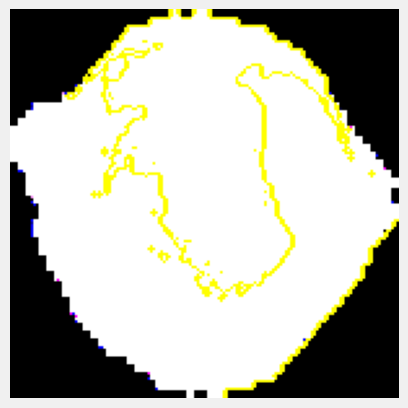

In [46]:
import lime
import lime.lime_image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from skimage.segmentation import mark_boundaries
from PIL import Image  
import matplotlib.pyplot as plt
import numpy as np

model = load_model('/kaggle/working/model1.h5')

explainer = lime.lime_image.LimeImageExplainer()

img_path = '/kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_128.png'
img = Image.open(img_path).resize((150, 150))
img = np.array(img)

if len(img.shape) == 2:
    img = np.stack((img,)*3, axis=-1)

img = preprocess_input(img)

def predict_fn(images):
    processed_images = np.array([preprocess_input(image) for image in images])
    return model.predict(processed_images)

explanation = explainer.explain_instance(img, predict_fn, top_labels=5, hide_color=0, num_samples=1000)

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)

plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.axis('off')
plt.savefig("Cyst.png", dpi=300, bbox_inches='tight')

plt.show()

  0%|          | 0/7998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.85s/it]               


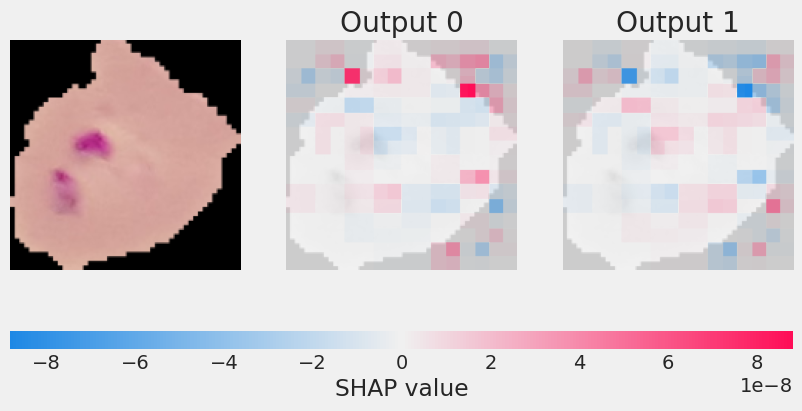

In [47]:
import os
import numpy as np
import tensorflow as tf
import shap
from tensorflow.keras.models import load_model

dataset_dir = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"

image_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_165.png"

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [150, 150])  
    image = tf.cast(image, tf.float32) / 255.0   
    return image.numpy()

image = preprocess_image(image_path)

model = load_model('/kaggle/working/model1.h5')

def f(x):
    tmp = x.copy()
    return model(tmp)

masker_blur = shap.maskers.Image("blur(150,150)", shape=(150, 150, 3))

explainer_blur = shap.Explainer(f, masker_blur)

shap_values_fine = explainer_blur(image[np.newaxis, :, :, :], max_evals=8000, outputs=shap.Explanation.argsort.flip[:8])

shap.image_plot(shap_values_fine)

#fig = plt.figure(figsize=(10, 10))
#shap.image_plot(shap_values_fine, show=False)
plt.show()

  0%|          | 0/7998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:18, 18.98s/it]               


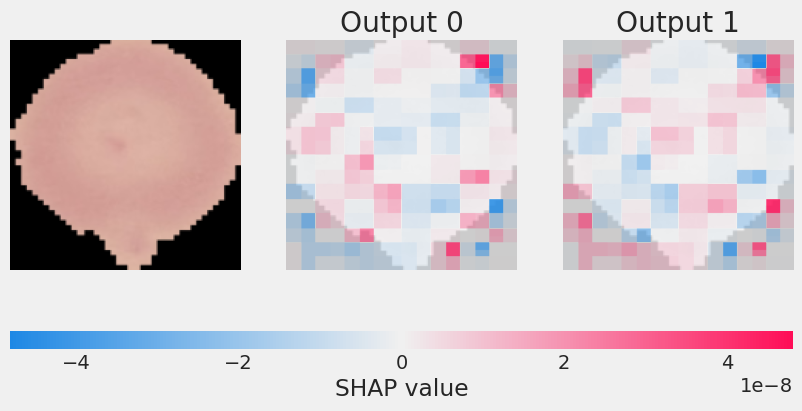

In [48]:
import os
import numpy as np
import tensorflow as tf
import shap
from tensorflow.keras.models import load_model

dataset_dir = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"

image_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_25.png"

def preprocess_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [150, 150])  
    image = tf.cast(image, tf.float32) / 255.0   
    return image.numpy()

image = preprocess_image(image_path)

model = load_model('/kaggle/working/model1.h5')

def f(x):
    tmp = x.copy()
    return model(tmp)

masker_blur = shap.maskers.Image("blur(150,150)", shape=(150, 150, 3))

explainer_blur = shap.Explainer(f, masker_blur)

shap_values_fine = explainer_blur(image[np.newaxis, :, :, :], max_evals=8000, outputs=shap.Explanation.argsort.flip[:8])

shap.image_plot(shap_values_fine)

#fig = plt.figure(figsize=(10, 10))
#shap.image_plot(shap_values_fine, show=False)
plt.show()

In [57]:
from keras.applications import ResNet50
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
resnet_base.trainable = False

inputs = Input(shape=(150, 150, 3))

x = resnet_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(2,activation='softmax')(x)
resnet_model = Model(inputs, outputs)

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    
)

resnet_model.fit(train_gen, epochs=5, validation_data=valid_gen)

Epoch 1/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.8654 - loss: 0.3431 - val_accuracy: 0.9266 - val_loss: 0.1842
Epoch 2/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9138 - loss: 0.2171 - val_accuracy: 0.9351 - val_loss: 0.1645
Epoch 3/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.9215 - loss: 0.2019 - val_accuracy: 0.9379 - val_loss: 0.1687
Epoch 4/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9264 - loss: 0.1922 - val_accuracy: 0.9412 - val_loss: 0.1542
Epoch 5/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9287 - loss: 0.1850 - val_accuracy: 0.9428 - val_loss: 0.1507


In [58]:
test_loss, test_acc = resnet_model.evaluate(test_gen, verbose=0)
print('\naccuracy:', test_acc, '  loss: ',test_loss)


accuracy: 0.9347037672996521   loss:  0.16888530552387238


In [59]:
from keras.applications import VGG16
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
vgg16_base.trainable = False

inputs = Input(shape=(150, 150, 3))

x = vgg16_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(2, activation='softmax')(x)
vgg16_model = Model(inputs, outputs)

vgg16_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.fit(train_gen, epochs=20, validation_data=valid_gen)

Epoch 1/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.8553 - loss: 0.7794 - val_accuracy: 0.9291 - val_loss: 0.1772
Epoch 2/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9270 - loss: 0.1996 - val_accuracy: 0.9351 - val_loss: 0.1534
Epoch 3/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - accuracy: 0.9315 - loss: 0.1828 - val_accuracy: 0.9416 - val_loss: 0.1435
Epoch 4/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.9392 - loss: 0.1699 - val_accuracy: 0.9412 - val_loss: 0.1649
Epoch 5/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9404 - loss: 0.1647 - val_accuracy: 0.9424 - val_loss: 0.1545
Epoch 6/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9396 - loss: 0.1642 - val_accuracy: 0.9456 - val_loss: 0.1406
Epoch 7/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9418 - loss: 0.1640 - val_accuracy: 0.9444 - val_loss: 0.1464
Epoch 8/20
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.9424 - loss: 0.1545 -

In [60]:
test_loss, test_acc = vgg16_model.evaluate(test_gen, verbose=0)
print('\naccuracy:', test_acc, '  loss: ',test_loss)


accuracy: 0.9480048418045044   loss:  0.15834414958953857


In [66]:
from keras.applications import MobileNetV2
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

mobilenetv2_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
mobilenetv2_base.trainable = False

inputs = Input(shape=(150, 150, 3))

x = mobilenetv2_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(2, activation='softmax')(x)
mobilenetv2_model = Model(inputs, outputs)

mobilenetv2_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenetv2_model.fit(train_gen, epochs=5, validation_data=valid_gen)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 64s 76ms/step - accuracy: 0.7151 - loss: 0.5942 - val_accuracy: 0.7989 - val_loss: 0.4193
Epoch 2/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.7961 - loss: 0.4360 - val_accuracy: 0.8198 - val_loss: 0.3869
Epoch 3/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.8024 - loss: 0.4269 - val_accuracy: 0.8069 - val_loss: 0.3937
Epoch 4/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.7997 - loss: 0.4183 - val_accuracy: 0.8343 - val_loss: 0.3723
Epoch 5/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.8133 - loss: 0.4000 - val_accuracy: 0.7981 - val_loss: 0.4153


In [67]:
test_loss, test_acc = mobilenetv2_model.evaluate(test_gen, verbose=0)
print('\naccuracy:', test_acc, '  loss: ',test_loss)


accuracy: 0.7883917689323425   loss:  0.43460434675216675


In [68]:
from keras.applications import DenseNet121
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

densenet121_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
densenet121_base.trainable = False

inputs = Input(shape=(150, 150, 3))

x = densenet121_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(2, activation='softmax')(x)
densenet121_model = Model(inputs, outputs)

densenet121_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

densenet121_model.fit(train_gen, epochs=5, validation_data=valid_gen)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 103s 106ms/step - accuracy: 0.7290 - loss: 1.3146 - val_accuracy: 0.8581 - val_loss: 0.3868
Epoch 2/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.8095 - loss: 0.4018 - val_accuracy: 0.8819 - val_loss: 0.3187
Epoch 3/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 49s 68ms/step - accuracy: 0.8375 - loss: 0.3740 - val_accuracy: 0.8972 - val_loss: 0.2633
Epoch 4/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 49s 68ms/step - accuracy: 0.8245 - loss: 0.3765 - val_accuracy: 0.8920 - val_loss: 0.2759
Epoch 5/5
707/707 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.8600 - loss: 0.3382 - val_accuracy: 0.8867 - val_loss: 0.3132


In [69]:
test_loss, test_acc = densenet121_model.evaluate(test_gen, verbose=0)
print('\naccuracy:', test_acc, '  loss: ',test_loss)


accuracy: 0.8782749176025391   loss:  0.31343182921409607
